# Статистическая проверка гипотезы 2. Stochastic RPML + CVaR.

Данный ноутбук предназначен для проверки гипотезы о снижении риска кассового разрыва при переходе от детерминистической RPML к стохастической постановке с `CVaR`.

**Формулировка гипотезы 2:**
Если расширить детерминистическую RPML-модель до стохастической постановки со сценариями дохода и оптимизацией вида `min cost + λ * CVaR`, а также ограничить частоту кассового разрыва условием `Cash Shortfall Rate <= beta`, то можно получить более устойчивый план выплат и снизить риск кассового разрыва.

**Основные метрики:**
- `CVaR shortfall`
- `Cash Shortfall Rate`
- `Total payment cost` как цена устойчивости.

In [1]:
from __future__ import annotations

import json
from pathlib import Path
from typing import Any

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 160)

## 1. Загрузка результатов H2

Ноутбук поддерживает два источника:
- агрегированный CSV (`stochastic_cvar/stochastic_cvar_results.csv`),
- checkpoint JSONL (`checkpoint/stochastic_cvar_experiment_results_checkpoint.jsonl`).

Ниже по умолчанию указан актуальный run для постановки `min cost + λ * CVaR` при ограничении `Cash Shortfall Rate <= beta`.

Если `RUN_ID` не задан, выбирается самый свежий run с артефактами H2.

In [2]:
RUNS_ROOT = Path("tmp/runs")
RUN_ID: str | None = "20260404-151954_base_h2cvar_n4_tl60_m30_a95_l1p0_b0p5_7e4d80d2"


def _artifact_paths(run_dir: Path) -> tuple[Path, Path]:
    csv_path = run_dir / "stochastic_cvar" / "stochastic_cvar_results.csv"
    checkpoint_path = run_dir / "checkpoint" / "stochastic_cvar_experiment_results_checkpoint.jsonl"
    return csv_path, checkpoint_path


def _run_has_h2_artifacts(run_dir: Path) -> bool:
    csv_path, checkpoint_path = _artifact_paths(run_dir)
    return csv_path.exists() or checkpoint_path.exists()


def resolve_h2_run_dir(runs_root: Path, run_id: str | None = None) -> Path:
    if run_id:
        run_dir = runs_root / run_id
        if not run_dir.exists():
            raise FileNotFoundError(f"Run not found: {run_dir}")
        if not _run_has_h2_artifacts(run_dir):
            raise FileNotFoundError(f"No H2 artifacts in run: {run_dir}")
        return run_dir

    candidates = [d for d in runs_root.iterdir() if d.is_dir() and _run_has_h2_artifacts(d)]
    if not candidates:
        raise FileNotFoundError(f"No H2 runs found in: {runs_root}")
    candidates.sort(key=lambda d: d.stat().st_mtime, reverse=True)
    return candidates[0]


def _load_h2_from_checkpoint(path: Path) -> pd.DataFrame:
    rows: list[dict[str, Any]] = []
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            rows.append(json.loads(line))
    if not rows:
        raise ValueError(f"Checkpoint is empty: {path}")
    return pd.DataFrame(rows)


def load_h2_results(run_dir: Path) -> pd.DataFrame:
    csv_path, checkpoint_path = _artifact_paths(run_dir)
    if csv_path.exists():
        return pd.read_csv(csv_path)
    if checkpoint_path.exists():
        return _load_h2_from_checkpoint(checkpoint_path)
    raise FileNotFoundError(f"No H2 results found in run: {run_dir}")


RUN_DIR = resolve_h2_run_dir(RUNS_ROOT, RUN_ID)
df_h2 = load_h2_results(RUN_DIR)

print(f"Используется run: {RUN_DIR.name}")
print(f"Строк в наборе H2: {len(df_h2)}")
if "shortfall_rate_beta" in df_h2.columns:
    print(f"beta: {sorted(pd.Series(df_h2['shortfall_rate_beta']).dropna().unique().tolist())}")
print("\nКолонки:")
print(sorted(df_h2.columns))

Используется run: 20260404-151954_base_h2cvar_n4_tl60_m30_a95_l1p0_b0p5_7e4d80d2
Строк в наборе H2: 30
beta: [0.5]

Колонки:
['delta_cash_shortfall_rate', 'delta_cvar_shortfall', 'delta_total_payment_cost', 'deterministic_cash_shortfall_rate', 'deterministic_cost', 'deterministic_cvar_shortfall', 'deterministic_gap', 'deterministic_max_shortfall', 'deterministic_mean_shortfall', 'deterministic_median_shortfall', 'deterministic_p90_shortfall', 'deterministic_solve_time', 'deterministic_status', 'instance_name', 'n_loans', 'n_scenarios', 'risk_alpha', 'risk_lambda', 'shortfall_epsilon', 'shortfall_rate_beta', 'stochastic_cash_shortfall_rate', 'stochastic_cvar_shortfall', 'stochastic_gap', 'stochastic_max_shortfall', 'stochastic_mean_shortfall', 'stochastic_median_shortfall', 'stochastic_objective_value', 'stochastic_p90_shortfall', 'stochastic_solve_time', 'stochastic_status', 'stochastic_total_payment_cost']


## 2. Подготовка данных и описательная статистика

Для тестов используем только строки, где оба решения (deterministic и stochastic) имеют допустимый статус: `OPTIMAL` или `FEASIBLE`.

In [3]:
VALID_STATUSES = {"OPTIMAL", "FEASIBLE"}

required_cols = [
    "deterministic_status",
    "stochastic_status",
    "deterministic_cvar_shortfall",
    "stochastic_cvar_shortfall",
    "deterministic_cash_shortfall_rate",
    "stochastic_cash_shortfall_rate",
    "stochastic_total_payment_cost",
]

missing = [c for c in required_cols if c not in df_h2.columns]
if missing:
    raise ValueError(f"В результатах отсутствуют колонки: {missing}")

det_cost_col = (
    "deterministic_total_payment_cost"
    if "deterministic_total_payment_cost" in df_h2.columns
    else "deterministic_cost"
)
if det_cost_col not in df_h2.columns:
    raise ValueError("Не найдена колонка детерминистической стоимости: deterministic_total_payment_cost/deterministic_cost")

df_usable = df_h2[
    df_h2["deterministic_status"].isin(VALID_STATUSES)
    & df_h2["stochastic_status"].isin(VALID_STATUSES)
].copy()

df_nonusable = df_h2.loc[~df_h2.index.isin(df_usable.index)].copy()

if "delta_cvar_shortfall" not in df_usable.columns:
    df_usable["delta_cvar_shortfall"] = (
        df_usable["stochastic_cvar_shortfall"] - df_usable["deterministic_cvar_shortfall"]
    )
if "delta_cash_shortfall_rate" not in df_usable.columns:
    df_usable["delta_cash_shortfall_rate"] = (
        df_usable["stochastic_cash_shortfall_rate"] - df_usable["deterministic_cash_shortfall_rate"]
    )
if "delta_total_payment_cost" not in df_usable.columns:
    df_usable["delta_total_payment_cost"] = (
        df_usable["stochastic_total_payment_cost"] - df_usable[det_cost_col]
    )

print(f"Всего строк: {len(df_h2)}")
print(f"Используемых строк: {len(df_usable)}")
print(f"Покрытие: {len(df_usable) / max(len(df_h2), 1):.1%}")

loan_count_col = "loan_count" if "loan_count" in df_usable.columns else "n_loans" if "n_loans" in df_usable.columns else None
if loan_count_col is not None:
    print("\nРазбивка по количеству долгов:")
    print(df_usable[loan_count_col].value_counts().sort_index().to_string())

if "shortfall_rate_beta" in df_usable.columns:
    beta_value = float(df_usable["shortfall_rate_beta"].dropna().iloc[0])
    print(f"\nОграничение beta: {beta_value:.3f}")
    print(f"Максимальный stochastic Cash Shortfall Rate: {df_usable['stochastic_cash_shortfall_rate'].max():.3f}")
    print(
        "Количество решений, где ограничение активно (rate == beta): "
        f"{int(np.sum(np.isclose(df_usable['stochastic_cash_shortfall_rate'], beta_value)))}"
    )

if len(df_nonusable) > 0:
    print("\nНеиспользуемые строки:")
    display(df_nonusable[["instance_name", "deterministic_status", "stochastic_status"]])

display(
    df_usable[
        [
            "delta_cvar_shortfall",
            "delta_cash_shortfall_rate",
            "delta_total_payment_cost",
        ]
    ].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9])
)

Всего строк: 30
Используемых строк: 29
Покрытие: 96.7%

Разбивка по количеству долгов:
n_loans
4    29

Ограничение beta: 0.500
Максимальный stochastic Cash Shortfall Rate: 0.500
Количество решений, где ограничение активно (rate == beta): 19

Неиспользуемые строки:


,instance_name,deterministic_status,stochastic_status
1,Deudas_4_0_0_0_4_120_fijo_fijo_1,OPTIMAL,NOT_SOLVED


,delta_cvar_shortfall,delta_cash_shortfall_rate,delta_total_payment_cost
count,29.000000,29.000000,2.900000e+01
mean,-25490.417630,-0.267241,8.222598e+03
std,39324.836788,0.220906,2.047272e+04
min,-116414.921706,-0.750000,-6.673965e+04
10%,-87899.664777,-0.625000,-6.941363e+03
25%,-47321.194423,-0.375000,-2.328306e-10
50%,-12356.337967,-0.250000,6.968312e+03
75%,-2304.007071,-0.125000,1.744957e+04
90%,18137.602031,0.000000,2.671222e+04
max,28017.291560,0.000000,5.951872e+04


## 3. Визуальный анализ

Отрицательное значение `delta` означает, что стохастическая модель лучше по соответствующей метрике.

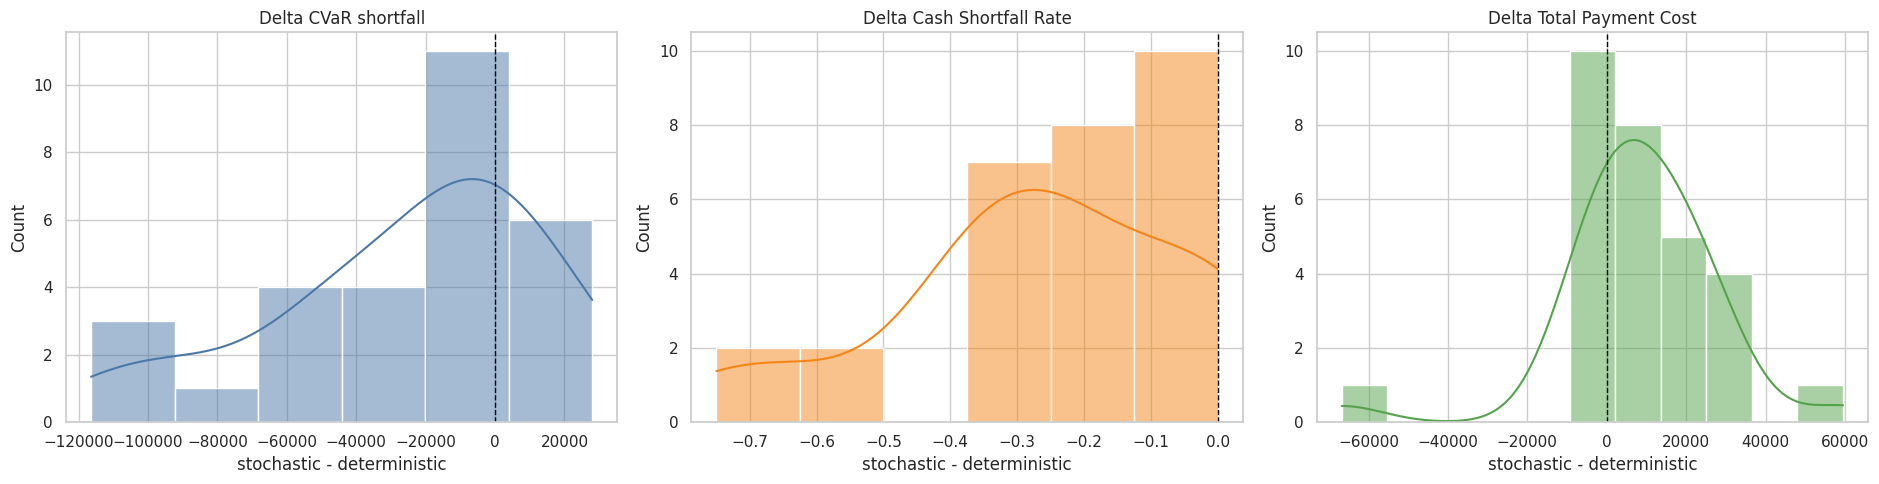

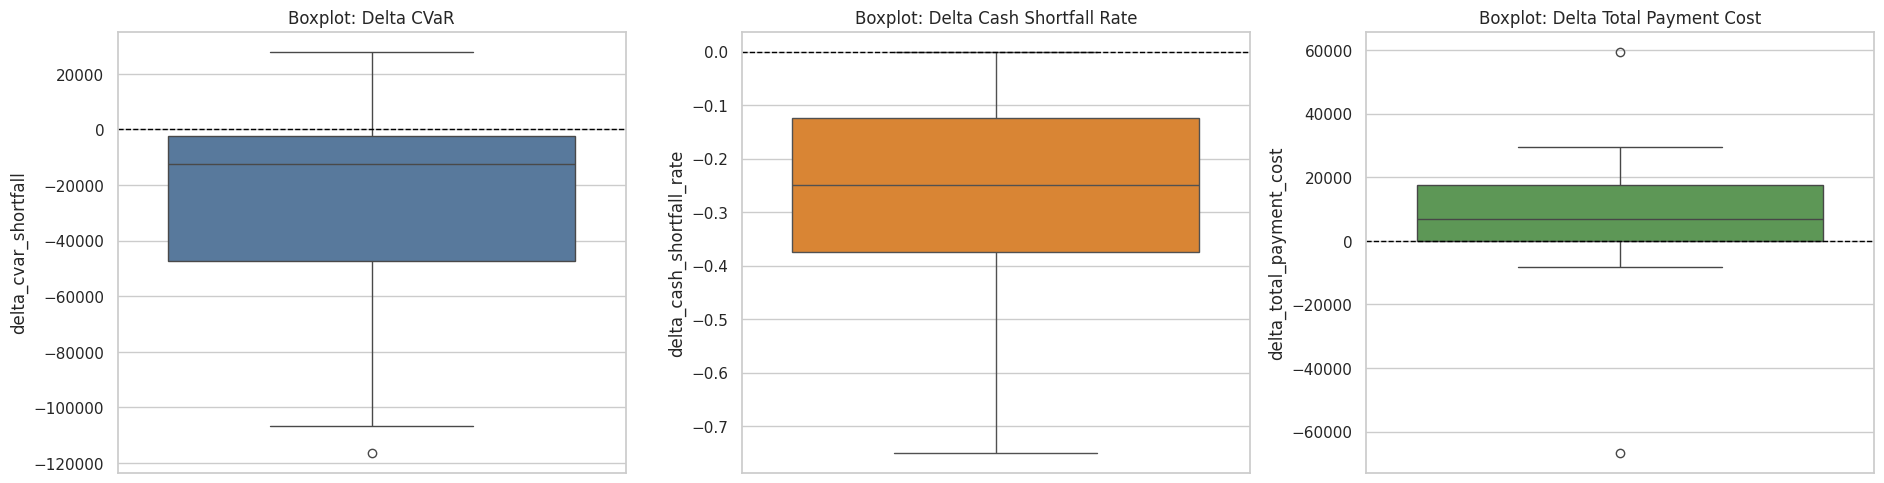

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(19, 5))

sns.histplot(df_usable["delta_cvar_shortfall"], kde=True, ax=axes[0], color="#4c78a8")
axes[0].axvline(0.0, color="black", linestyle="--", linewidth=1)
axes[0].set_title("Delta CVaR shortfall")
axes[0].set_xlabel("stochastic - deterministic")

sns.histplot(df_usable["delta_cash_shortfall_rate"], kde=True, ax=axes[1], color="#f58518")
axes[1].axvline(0.0, color="black", linestyle="--", linewidth=1)
axes[1].set_title("Delta Cash Shortfall Rate")
axes[1].set_xlabel("stochastic - deterministic")

sns.histplot(df_usable["delta_total_payment_cost"], kde=True, ax=axes[2], color="#54a24b")
axes[2].axvline(0.0, color="black", linestyle="--", linewidth=1)
axes[2].set_title("Delta Total Payment Cost")
axes[2].set_xlabel("stochastic - deterministic")

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(19, 5))

sns.boxplot(y=df_usable["delta_cvar_shortfall"], ax=axes[0], color="#4c78a8")
axes[0].axhline(0.0, color="black", linestyle="--", linewidth=1)
axes[0].set_title("Boxplot: Delta CVaR")

sns.boxplot(y=df_usable["delta_cash_shortfall_rate"], ax=axes[1], color="#f58518")
axes[1].axhline(0.0, color="black", linestyle="--", linewidth=1)
axes[1].set_title("Boxplot: Delta Cash Shortfall Rate")

sns.boxplot(y=df_usable["delta_total_payment_cost"], ax=axes[2], color="#54a24b")
axes[2].axhline(0.0, color="black", linestyle="--", linewidth=1)
axes[2].set_title("Boxplot: Delta Total Payment Cost")

plt.tight_layout()
plt.show()

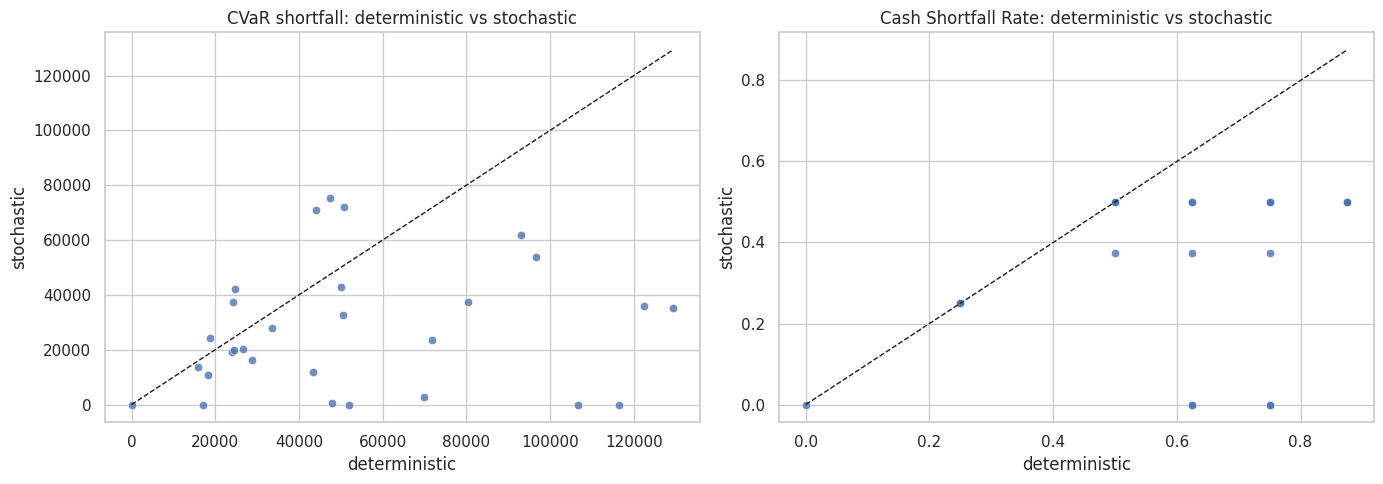

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(
    data=df_usable,
    x="deterministic_cvar_shortfall",
    y="stochastic_cvar_shortfall",
    ax=axes[0],
    alpha=0.8,
)
max_cvar = float(
    max(df_usable["deterministic_cvar_shortfall"].max(), df_usable["stochastic_cvar_shortfall"].max())
)
axes[0].plot([0, max_cvar], [0, max_cvar], "k--", linewidth=1)
axes[0].set_title("CVaR shortfall: deterministic vs stochastic")
axes[0].set_xlabel("deterministic")
axes[0].set_ylabel("stochastic")

sns.scatterplot(
    data=df_usable,
    x="deterministic_cash_shortfall_rate",
    y="stochastic_cash_shortfall_rate",
    ax=axes[1],
    alpha=0.8,
)
max_rate = float(
    max(
        df_usable["deterministic_cash_shortfall_rate"].max(),
        df_usable["stochastic_cash_shortfall_rate"].max(),
    )
)
axes[1].plot([0, max_rate], [0, max_rate], "k--", linewidth=1)
axes[1].set_title("Cash Shortfall Rate: deterministic vs stochastic")
axes[1].set_xlabel("deterministic")
axes[1].set_ylabel("stochastic")

plt.tight_layout()
plt.show()

## 4. Статистическое тестирование

Для гипотезы 2 используется парное сравнение constrained `stochastic` и `deterministic` по одним и тем же инстансам.

- Базовый непараметрический тест: **Wilcoxon signed-rank**.
- Дополнительно: **парный t-test** как проверка устойчивости вывода.
- Для метрик риска (`CVaR`, `Cash Shortfall Rate`) используется односторонняя альтернатива `less`.
- Для `Total payment cost` используется двусторонняя проверка, так как здесь нас интересует цена устойчивости, а не строгое направление эффекта.

In [6]:
def run_paired_tests(delta: pd.Series, metric_name: str, alternative: str = "two-sided") -> None:
    x = delta.dropna().to_numpy(dtype=float)
    if x.size == 0:
        print(f"\n=== {metric_name} ===")
        print("Нет данных для тестирования.")
        return

    print(f"\n=== {metric_name} ===")
    print(f"n = {x.size}")
    print(f"mean(delta) = {x.mean():.6f}")
    print(f"median(delta) = {np.median(x):.6f}")

    if x.size >= 3:
        shapiro_stat, shapiro_p = stats.shapiro(x)
        print(f"Shapiro-Wilk p-value = {shapiro_p:.6g}")
    else:
        print("Shapiro-Wilk не выполняется: слишком мало наблюдений.")

    try:
        wilcoxon_res = stats.wilcoxon(x, alternative=alternative, zero_method="wilcox")
        print(f"Wilcoxon ({alternative}) p-value = {wilcoxon_res.pvalue:.6g}")
    except ValueError as e:
        print(f"Wilcoxon не выполнен: {e}")

    if alternative == "less":
        t_stat, t_p_two_sided = stats.ttest_1samp(x, popmean=0.0)
        t_p_one_sided = t_p_two_sided / 2 if t_stat < 0 else 1.0 - t_p_two_sided / 2
        print(f"Paired t-test (one-sided, less) p-value = {t_p_one_sided:.6g}")
    else:
        t_stat, t_p = stats.ttest_1samp(x, popmean=0.0)
        print(f"Paired t-test ({alternative}) p-value = {t_p:.6g}")


run_paired_tests(df_usable["delta_cvar_shortfall"], "Delta CVaR shortfall", alternative="less")
run_paired_tests(df_usable["delta_cash_shortfall_rate"], "Delta Cash Shortfall Rate", alternative="less")
run_paired_tests(df_usable["delta_total_payment_cost"], "Delta Total Payment Cost", alternative="two-sided")


=== Delta CVaR shortfall ===
n = 29
mean(delta) = -25490.417630
median(delta) = -12356.337967
Shapiro-Wilk p-value = 0.0357063
Wilcoxon (less) p-value = 0.00142693
Paired t-test (one-sided, less) p-value = 0.000807584

=== Delta Cash Shortfall Rate ===
n = 29
mean(delta) = -0.267241
median(delta) = -0.250000
Shapiro-Wilk p-value = 0.00611041
Wilcoxon (less) p-value = 1.68442e-05
Paired t-test (one-sided, less) p-value = 2.31722e-07

=== Delta Total Payment Cost ===
n = 29
mean(delta) = 8222.598104
median(delta) = 6968.312482
Shapiro-Wilk p-value = 0.000781178
Wilcoxon (two-sided) p-value = 0.00275913
Paired t-test (two-sided) p-value = 0.0392405


In [7]:
beta_summary = (
    float(df_usable["shortfall_rate_beta"].dropna().iloc[0])
    if "shortfall_rate_beta" in df_usable.columns and not df_usable["shortfall_rate_beta"].dropna().empty
    else None
)

summary = {
    "n_total": int(len(df_h2)),
    "n_usable": int(len(df_usable)),
    "n_nonusable": int(len(df_h2) - len(df_usable)),
    "coverage": float(len(df_usable) / max(len(df_h2), 1)),
    "shortfall_rate_beta": beta_summary,
    "stochastic_rate_max": float(df_usable["stochastic_cash_shortfall_rate"].max()),
    "stochastic_rate_at_beta_count": (
        int(np.sum(np.isclose(df_usable["stochastic_cash_shortfall_rate"], beta_summary)))
        if beta_summary is not None
        else None
    ),
    "delta_cvar_mean": float(df_usable["delta_cvar_shortfall"].mean()),
    "delta_cvar_median": float(df_usable["delta_cvar_shortfall"].median()),
    "delta_cash_rate_mean": float(df_usable["delta_cash_shortfall_rate"].mean()),
    "delta_cash_rate_median": float(df_usable["delta_cash_shortfall_rate"].median()),
    "delta_cost_mean": float(df_usable["delta_total_payment_cost"].mean()),
    "delta_cost_median": float(df_usable["delta_total_payment_cost"].median()),
}

pd.Series(summary, name="H2 summary")

n_total                             30.000000
n_usable                            29.000000
n_nonusable                          1.000000
coverage                             0.966667
shortfall_rate_beta                  0.500000
stochastic_rate_max                  0.500000
stochastic_rate_at_beta_count       19.000000
delta_cvar_mean                 -25490.417630
delta_cvar_median               -12356.337967
delta_cash_rate_mean                -0.267241
delta_cash_rate_median              -0.250000
delta_cost_mean                   8222.598104
delta_cost_median                 6968.312482
Name: H2 summary, dtype: float64

## 5. Интерпретация

Интерпретируйте результаты по знаку `delta = stochastic - deterministic`:
- `delta < 0` по `CVaR shortfall` и `Cash Shortfall Rate` поддерживает гипотезу 2;
- `delta > 0` по `Total payment cost` означает, что устойчивость достигается ценой роста выплат;
- `stochastic_cash_shortfall_rate <= beta` показывает, что ограничение действительно соблюдается в итоговом решении;
- большое число наблюдений с `rate == beta` означает, что ограничение активно и реально влияет на оптимальный план;
- итоговый вывод делается по совокупности эффектов, p-value и изменению solver coverage.